In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="2"
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from isolation_forest import ExtendedIsolationForest
from balif import Balif

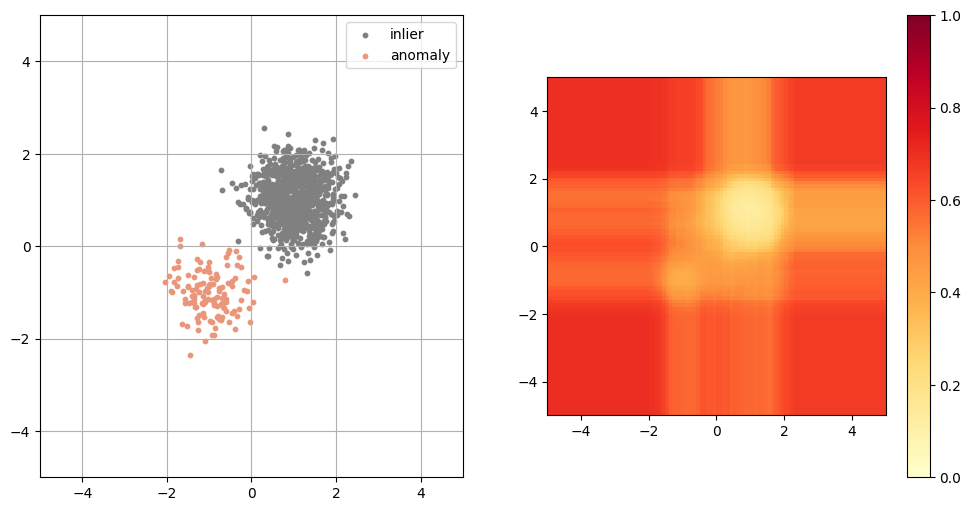

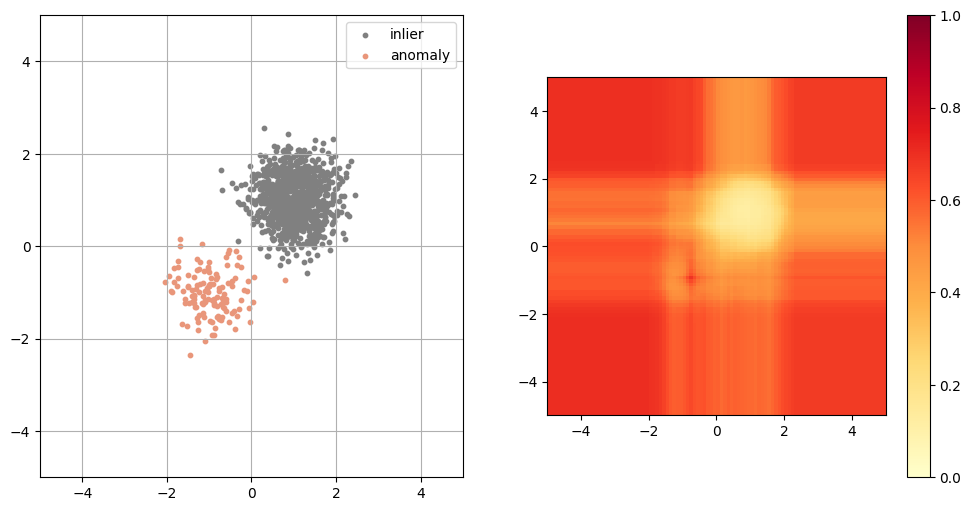

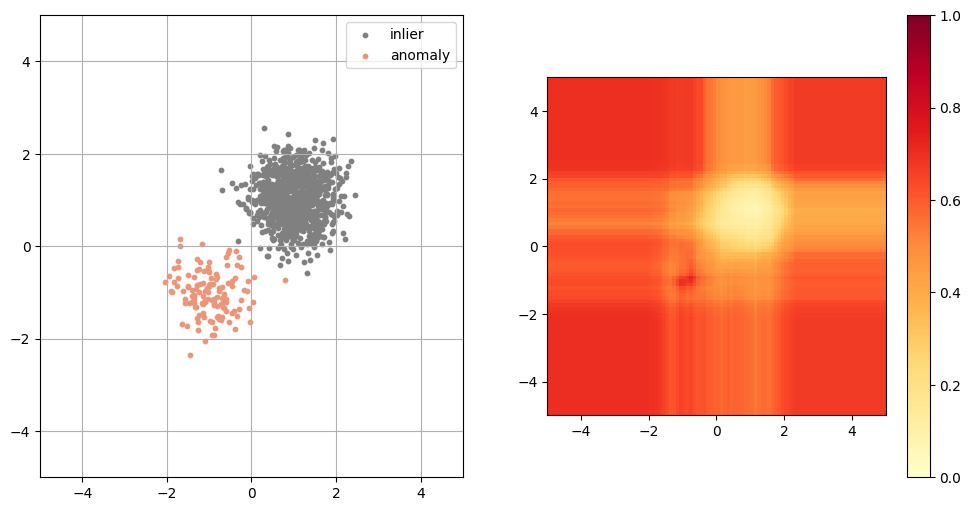

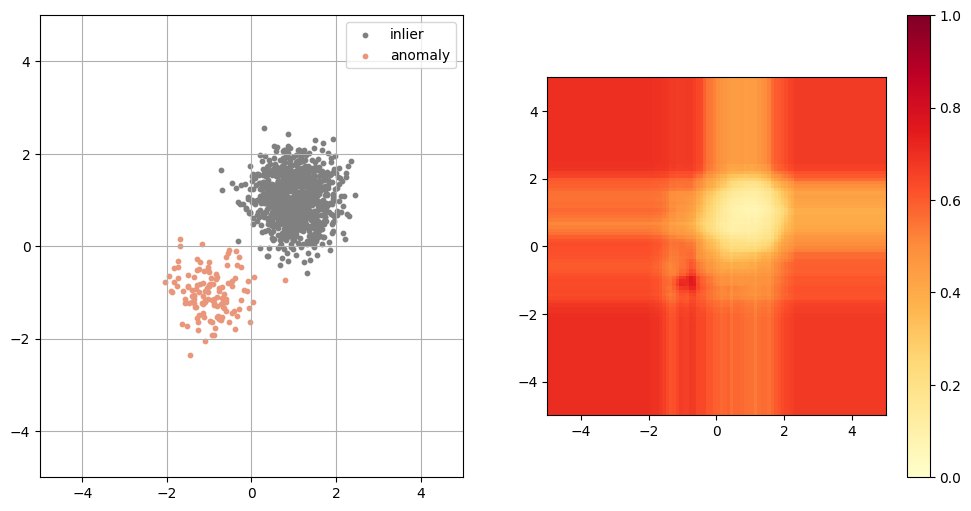

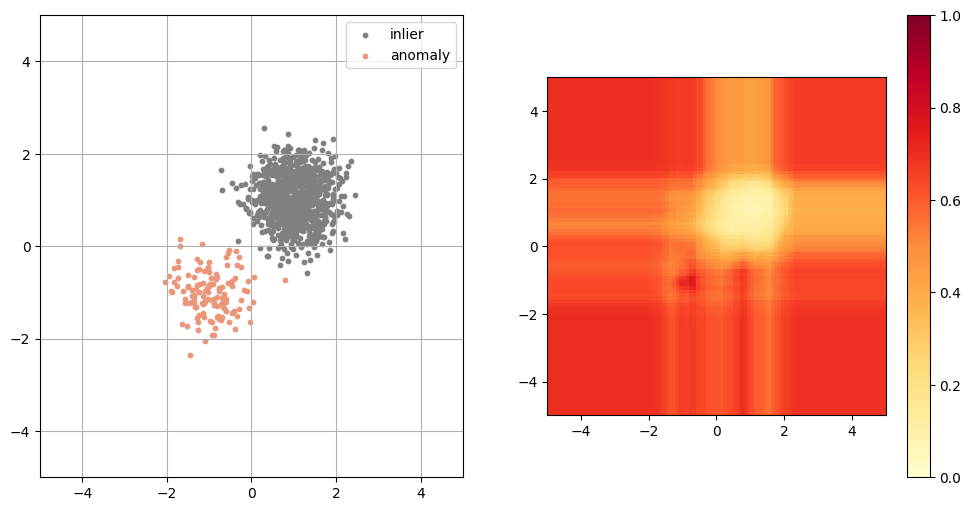

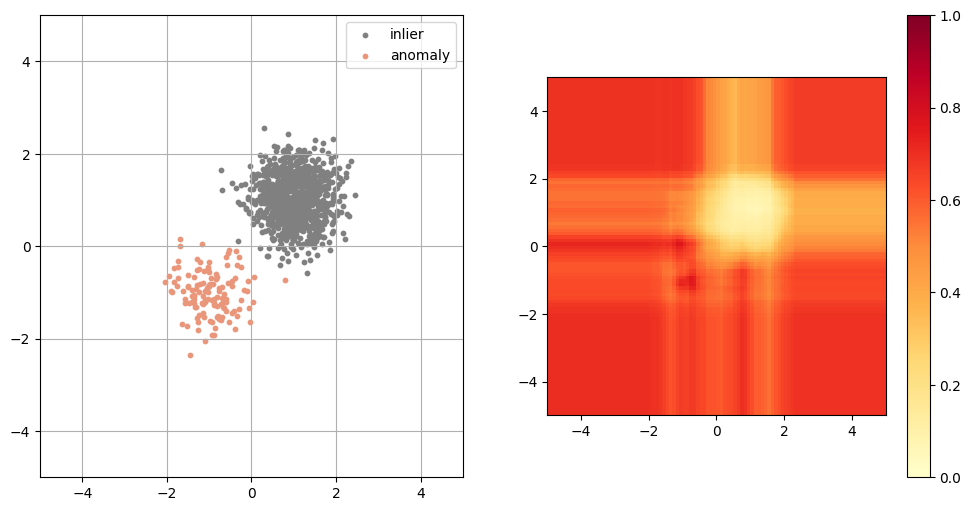

In [2]:
n_trees = 128
subsample_size = 256
hyperplane_components = 1

rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42))
data_anomaly = 0.5*jax.random.normal(rng_data, (128, 2)) - 1
data_inlier = 0.5*jax.random.normal(rng_data, (1024, 2)) + 1
data = jnp.concatenate([data_anomaly, data_inlier], axis=0)
forest = Balif.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components)

X, Y = jnp.meshgrid(jnp.linspace(-5, 5, 100), jnp.linspace(-5, 5, 100))
coord = jnp.stack([X.flatten(), Y.flatten()]).T

def plot_scores(scores):
    plt.figure(figsize=(12, 6))
    plt.subplot(122)
    plt.imshow(scores.reshape(100, 100), extent=(-5, 5, -5, 5), cmap="YlOrRd", origin="lower", vmin=0, vmax=1)
    plt.colorbar()
    plt.subplot(121)
    plt.scatter(data_inlier[:, 0], data_inlier[:, 1], marker="o", c="grey", s=10, label="inlier")
    plt.scatter(data_anomaly[:, 0], data_anomaly[:, 1], marker="o", c="darksalmon", s=10, label="anomaly")
    plt.legend()
    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.grid()
    plt.show()


N_labels = 5
plot_scores(forest.score_samples(coord))
for i in range(N_labels):
    forest = forest.update(data_anomaly[i], is_anomaly=True)
    forest = forest.update(data_inlier[i], is_anomaly=False)
    plot_scores(forest.score_samples(coord))

In [3]:
n_trees = 128
subsample_size = 256
n_dim = 2
hyperplane_components = 1

In [4]:
rng_data, rng_forest = jax.random.split(jax.random.PRNGKey(42))
data = jax.random.normal(rng_data, (10000, n_dim))
forest = Balif.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components)
scores = forest.score_samples(data)
%timeit Balif.fit(rng_forest, data, n_trees, subsample_size, hyperplane_components).node_sizes.block_until_ready()
%timeit forest.score_samples(data).block_until_ready()
%timeit forest.update(data[0], is_anomaly=True).node_sizes.block_until_ready()

1.01 ms ± 6.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.33 ms ± 18.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
521 µs ± 22.7 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
